<a href="https://colab.research.google.com/github/umair594/Decode-labs-data-analytics-internship/blob/main/Marketing_Campaign_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project 2: Marketing Campaign EDA**

# **Exploratory Data Analysis of Marketing Campaign Performance**

**Objective**

Analyze customer demographics, purchasing behavior, campaign responses, and spending patterns to identify business insights and improve future marketing strategy.

This matches your Project 2 requirement: calculate basic statistics, detect trends/outliers, and summarize key observations

# **Step 1: Import Libraries**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **Step 2: Load Dataset**

In [3]:
df = pd.read_csv("marketing_campaign.csv", sep=";")
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0


In [4]:
df.shape

(2240, 29)

# **Step 3: Understand the Dataset**

In [5]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


# **Step 4: Data Cleaning**

In [6]:
df["Income"] = df["Income"].fillna(df["Income"].median())

df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"])

df.drop(columns=["Z_CostContact", "Z_Revenue"], inplace=True)

# **Step 5: Feature Engineering**

Create strong, explainable features.

In [7]:
df["Age"] = 2026 - df["Year_Birth"]

df["Children"] = df["Kidhome"] + df["Teenhome"]

df["Total_Spend"] = (
    df["MntWines"] +
    df["MntFruits"] +
    df["MntMeatProducts"] +
    df["MntFishProducts"] +
    df["MntSweetProducts"] +
    df["MntGoldProds"]
)

df["Total_Purchases"] = (
    df["NumDealsPurchases"] +
    df["NumWebPurchases"] +
    df["NumCatalogPurchases"] +
    df["NumStorePurchases"]
)

df["Customer_Tenure_Days"] = (
    df["Dt_Customer"].max() - df["Dt_Customer"]
).dt.days

df["Any_Campaign_Accepted"] = (
    df[["AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3",
        "AcceptedCmp4", "AcceptedCmp5", "Response"]].sum(axis=1) > 0
).astype(int)

**Best features for your project:**

Age

Children

Total_Spend

Total_Purchases

Customer_Tenure_Days

Any_Campaign_Accepted

These are convincing because they convert raw columns into business-friendly metrics.

# **Step 6: Basic Statistics**

In [8]:
df[["Income", "Age", "Recency", "Total_Spend", "Total_Purchases"]].describe()

,Income,Age,Recency,Total_Spend,Total_Purchases
count,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,52237.975446,57.194196,49.109375,605.798214,14.862054
std,25037.955891,11.984069,28.962453,602.249288,7.677173
min,1730.000000,30.000000,0.000000,5.000000,0.000000
25%,35538.750000,49.000000,24.000000,68.750000,8.000000
50%,51381.500000,56.000000,49.000000,396.000000,15.000000
75%,68289.750000,67.000000,74.000000,1045.500000,21.000000
max,666666.000000,133.000000,99.000000,2525.000000,44.000000


# **Step 7: Distribution Analysis**

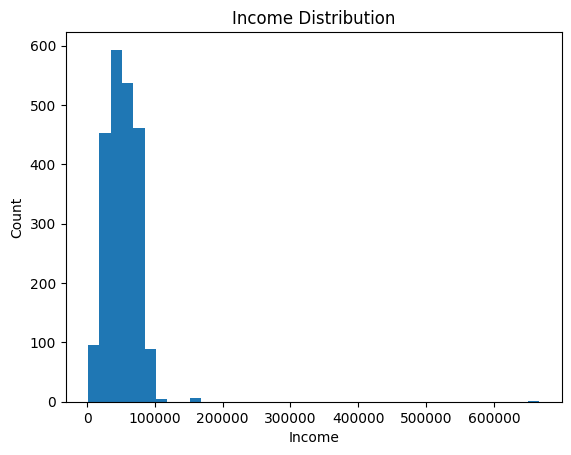

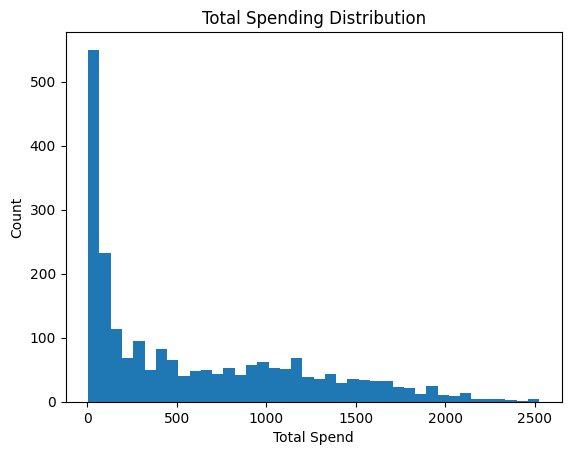

In [9]:
plt.hist(df["Income"], bins=40)
plt.title("Income Distribution")
plt.xlabel("Income")
plt.ylabel("Count")
plt.show()

plt.hist(df["Total_Spend"], bins=40)
plt.title("Total Spending Distribution")
plt.xlabel("Total Spend")
plt.ylabel("Count")
plt.show()

# **Step 8: Outlier Detection Using IQR**

In [10]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower) | (data[column] > upper)]
    return lower, upper, outliers.shape[0]

for col in ["Income", "Age", "Total_Spend", "Total_Purchases"]:
    print(col, detect_outliers_iqr(df, col))

Income (np.float64(-13587.75), np.float64(117416.25), 8)
Age (np.float64(22.0), np.float64(94.0), 3)
Total_Spend (np.float64(-1396.375), np.float64(2510.625), 3)
Total_Purchases (np.float64(-11.5), np.float64(40.5), 2)


# **Step 9: Spending Analysis**

In [11]:
spend_cols = [
    "MntWines", "MntFruits", "MntMeatProducts",
    "MntFishProducts", "MntSweetProducts", "MntGoldProds"
]

df[spend_cols].mean().sort_values(ascending=False)

,0
MntWines,303.935714
MntMeatProducts,166.950000
MntGoldProds,44.021875
MntFishProducts,37.525446
MntSweetProducts,27.062946
MntFruits,26.302232


# **Step 10: Education-Based Analysis**

In [12]:
df.groupby("Education").agg(
    Customers=("ID", "count"),
    Median_Income=("Income", "median"),
    Average_Spend=("Total_Spend", "mean"),
    Response_Rate=("Response", "mean")
).sort_values("Average_Spend", ascending=False)

,Customers,Median_Income,Average_Spend,Response_Rate
Education,,,,
PhD,486,55005.0,672.409465,0.207819
Graduation,1127,51651.0,619.898846,0.134871
Master,370,51044.5,611.781081,0.154054
2n Cycle,203,46891.0,496.527094,0.108374
Basic,54,20744.0,81.796296,0.037037


# **Step 11: Marital Status Analysis**

In [13]:
df.groupby("Marital_Status").agg(
    Customers=("ID", "count"),
    Median_Income=("Income", "median"),
    Average_Spend=("Total_Spend", "mean"),
    Response_Rate=("Response", "mean")
).sort_values("Response_Rate", ascending=False)

,Customers,Median_Income,Average_Spend,Response_Rate
Marital_Status,,,,
Absurd,2,72365.5,1192.500000,0.500000
YOLO,2,48432.0,424.000000,0.500000
Alone,3,35860.0,256.666667,0.333333
Widow,77,56551.0,738.818182,0.246753
Single,480,49277.5,606.483333,0.220833
Divorced,232,52683.0,610.629310,0.206897
Married,864,51521.0,590.802083,0.113426
Together,580,51381.5,608.387931,0.103448


# **Step 12: Campaign Response Analysis**

In [14]:
campaign_cols = [
    "AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3",
    "AcceptedCmp4", "AcceptedCmp5", "Response"
]

df[campaign_cols].mean().sort_values(ascending=False)

,0
Response,0.149107
AcceptedCmp4,0.074554
AcceptedCmp3,0.072768
AcceptedCmp5,0.072768
AcceptedCmp1,0.064286
AcceptedCmp2,0.013393


# **Step 13: Correlation Analysis**

In [15]:
corr = df.corr(numeric_only=True)

corr["Total_Spend"].sort_values(ascending=False).head(10)

,Total_Spend
Total_Spend,1.000000
MntWines,0.891839
MntMeatProducts,0.842965
NumCatalogPurchases,0.778577
Total_Purchases,0.753903
NumStorePurchases,0.674669
Income,0.664775
MntFishProducts,0.642818
MntFruits,0.614229
MntSweetProducts,0.603016


In [16]:
corr["Response"].sort_values(ascending=False).head(10)

,Response
Response,1.000000
Any_Campaign_Accepted,0.685062
AcceptedCmp5,0.326634
AcceptedCmp1,0.293982
Total_Spend,0.265298
AcceptedCmp3,0.254258
MntWines,0.247254
MntMeatProducts,0.236335
NumCatalogPurchases,0.220810
Customer_Tenure_Days,0.194481


# **Step 14: Visualization Code**

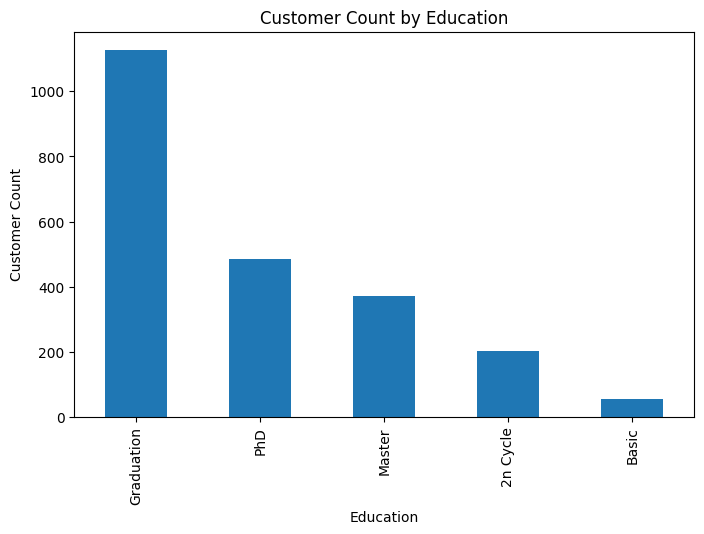

In [17]:
plt.figure(figsize=(8,5))
df["Education"].value_counts().plot(kind="bar")
plt.title("Customer Count by Education")
plt.xlabel("Education")
plt.ylabel("Customer Count")
plt.show()

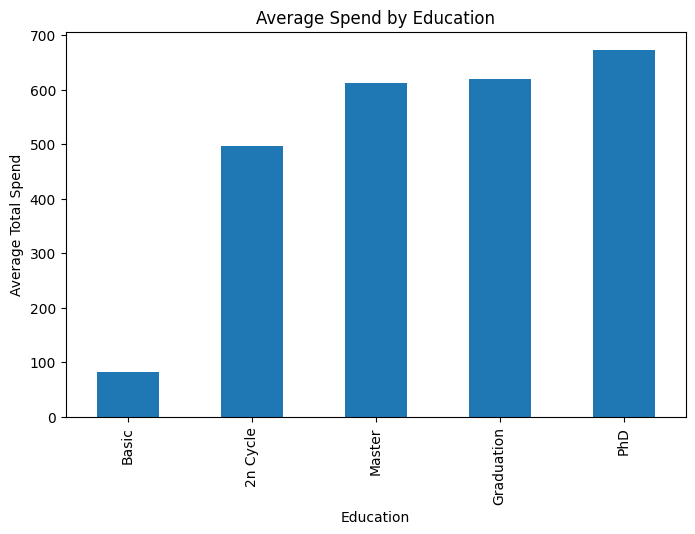

In [18]:
plt.figure(figsize=(8,5))
df.groupby("Education")["Total_Spend"].mean().sort_values().plot(kind="bar")
plt.title("Average Spend by Education")
plt.xlabel("Education")
plt.ylabel("Average Total Spend")
plt.show()

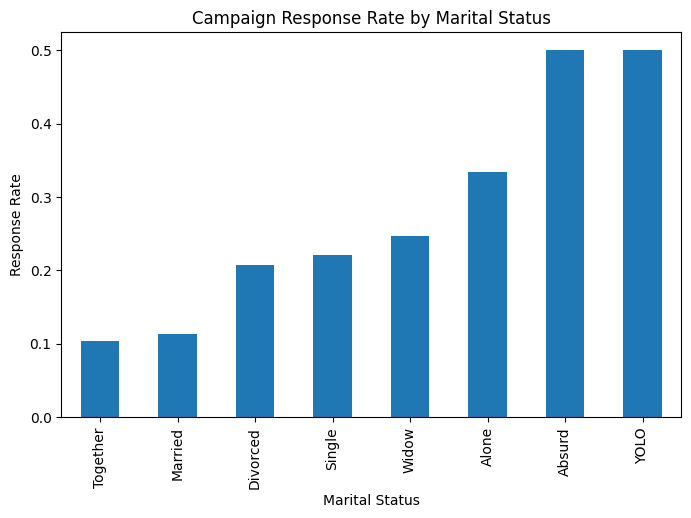

In [19]:
plt.figure(figsize=(8,5))
df.groupby("Marital_Status")["Response"].mean().sort_values().plot(kind="bar")
plt.title("Campaign Response Rate by Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Response Rate")
plt.show()

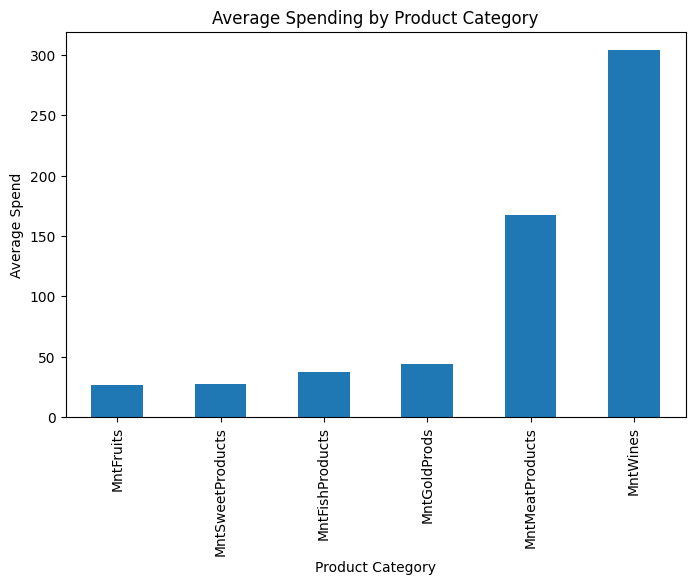

In [20]:
plt.figure(figsize=(8,5))
df[spend_cols].mean().sort_values().plot(kind="bar")
plt.title("Average Spending by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Average Spend")
plt.show()

# **Final Key Findings**

>The dataset contains 2240 customers and only one important missing column: Income.

>Customer spending is highly unequal. A small group of customers contributes much higher spending than the majority.

>Wine and meat products are the strongest revenue categories.

>Income has a strong positive relationship with total spending.

>Catalog purchases and store purchases are strongly connected with high customer spending.

>Customers who accepted previous campaigns are more likely to respond again.

>The final campaign response rate is only about 14.9%, meaning campaign targeting can be improved

>PhD, Master, and Graduation customers generally show stronger value than Basic education customers..

# **Business Recommendations**

>Target high-income and high-spending customers with premium wine and meat product campaigns.

>Use previous campaign acceptance as a key segmentation feature.

>**Create separate campaigns for:**

Premium customers

Discount-sensitive customers

High catalog buyers

Low engagement customers

>Do not remove spending outliers automatically. They may represent the most valuable customers.

>Improve campaign personalization because the general response rate is low.

This project analyzed a marketing campaign dataset of 2240 customers to understand customer demographics, spending behavior, campaign response, and purchasing patterns. The analysis found that customer spending is highly skewed, with a small number of customers generating significantly higher revenue. Wine and meat products are the strongest product categories. Income, catalog purchases, store purchases, and previous campaign acceptance are important indicators of customer value and campaign response. The overall campaign response rate is about 14.9%, showing that future campaigns should be more targeted and personalized. The business should focus on high-value customers, previous responders, and premium product buyers while designing separate strategies for low-income and discount-sensitive customers.

**The EDA shows that marketing performance can be improved through better customer segmentation. Instead of treating all customers equally, the company should focus on customers with high income, high total spending, and previous campaign acceptance. These customers are more likely to respond and generate higher revenue. EDA successfully converted raw customer data into business insights that can support smarter campaign decisions.**